<b><a href="https://github.com/dcruzeneil/dcruzeneil.github.io/blob/main/posts/perceptron-algorithm/perceptron.py">Implementation of the Perceptron Algorithm : <i>percepton.py</i></a></b>

# Introduction to the Perceptron Algorithm 
The Perceptron Algorithm is a linear classifier, which means that based on an object's properties it should be able to classify it as part of one group or another. This could be extended to a general problem. Given two features: $x_1$ - a person's salary, and $x_2$ - their age, how likely are they to buy a car? We can store, the two features in a single vector: $x_i = (x_1, x_2) \in R^2$. Alternatively, we can create a feature matrix $X$ and stack $x_1$ and $x_2$ onto that matrix. 

$$
X = 
\begin{bmatrix}
x_1\\
x_2
\end{bmatrix}
$$ 

For $n$ data points and $p$ features, the feature matrix $X$ will be an $n$ x $p$ matrix. To find a linear classifier, we start with a training set, where have access to the lablels - which can be $\{+1,-1\}$. Building up on the example of buying a car, $+1$ could mean the person is likely to buy a car, and $-1$ could mean the opposite. We start with bias as $b=0$ and initialize random weights for each feature. We then find the weighted sum - which is called the activation - $a$. Based on whether this activation (the activation's sign) matches with the label (the label's sign), we update the weights and bias. We have some iterations of the perceptron algorithm over the test data, the goal being to be able to correctly guess labels for the test data which the model has not seen before. Visually - for two features - we could imagine the two axes of a cartesian plane as the two features. Our goal is to find a hyperplane that can divide the data (which would be in the form of points) into two groups.      

# Implementing the Perceptron Algorithm  

In [1]:
#importing the necessary packages
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from perceptron import Perceptron 

In the following section, we are using the *make_blobs* function of sklearn.datasets to create synthetic data for our experimentation. In this case, we are creating two clusters of data, which are centered around two different areas - and have different labels $0$ and $1$. This synthetic data will be used to train our perceptron algorithm.

In [2]:
#arbitrarily setting the seed number to 123456 to ensure reproducibility
np.random.seed(12345)

#setting the number of points we want
n = 100
#setting the number of features = 2 for visualization purposes
features = 2

#using the make_blobs function to create 2 clusters of 100 data points
#X is the feature matrix - in this case n x features i.e. 100 x 2 
#y is the cluster labels - whether Alice ikes a book or not - in this case 0 or 1, instead of -1 and +1
X, y = make_blobs(n_samples = n, n_features = features, centers = [(-1.7,-1.7),(1.7,1.7)])

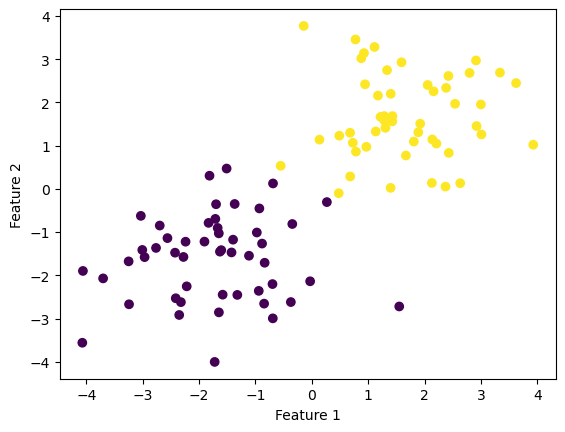

In [3]:
#plotting the clusters generated by the make_blobs function
fig = plt.scatter(X[:,0], X[:,1], c = y)
xLabel = plt.xlabel("Feature 1")
yLabel = plt.ylabel("Feature 2")

In the following section, we are calling the *fit* function of the Perceptron class. This function runs for a specified number of times, which in our case is <b>max_steps</b>. The function stops running either when we have reached the specified number of times, or when we achieve perfect accuracy in our classification. In each run, the dot product of the weight vector (which is randomly initialized) and the feature vector for a particular data point, is calculated. This is our predicted label. Based on how this predicted label compares to the actual label - we either update the weight vector, or leave it unchanged. 

<u>Update Mechanism of the Perceptron algorithm</u>: in the case where the predicted label does not match the actual label, the program modifies the weight vector! This can be explained as follow:

```python
if(yPrediction!=y[index]):
    yModified = 2*y[index] - 1
    self.w = np.add(self.w, yModified*X_[index,:])
```

We check for the condition in which the prediction label does not match the actual label. Then the idea is for the weight vector: $w = \{w_1, w_2, -b\}$, we need to create a new weight vector $w^{'} = \{w_1 + y_i * x_{i1}, w_2 + y_i * x_{i2}, -b + y_i\}$. In our case, since we are dealing with $0$s and $1$s, rather than the conventional $+1$s and $-1$s, we need to modify the $y_i$. For this purpose, a *yModified* variable is created which is $(2 * y_{i}) - 1$. Therefore, $1$ gets mapped to $1$, and $0$ gets mapped to $-1$. This is necessary because when using $0$ as a label, we run into the issue where $0$ leaves $w^{'} = \{w_1 + y_i * x_{i1}, w_2 + y_i * x_{i2}, -b + y_i\}$ unchanged, as $\{y_i * x_{i1}, y_i * x_{i2}, y_i\}$ are all $0$. 

In [4]:
#creating an instance of the Perceptron class
p = Perceptron()
#max_steps - number of times we will go over the dataset
p.fit(X, y, max_steps = 1500)

In the following section, we can see the final weight vector we achieved - which in this case led to perfect accuracy. This can be verified by looking at the history variable, which shows that a score of **1.0** was achieved at the end!

In [5]:
print(p.w)
print(p.history[-10:]) 

[ 1.71929051  2.78553289 -0.30455785]
[0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 1.0]


A visualization of how the accuracy of the classifier increases over the number of iteration. Using the *score* function, we can also see the final score, which in this case was **1.0** - perfect classification!

1.0


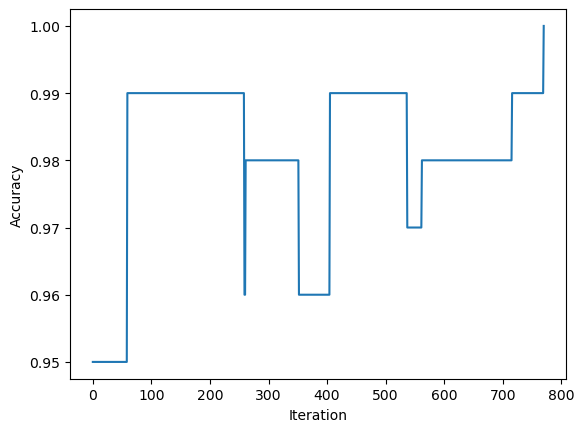

In [6]:
p.visualize_score()
print(p.score(X,y))

We can visualize the line which classifies the two objects:

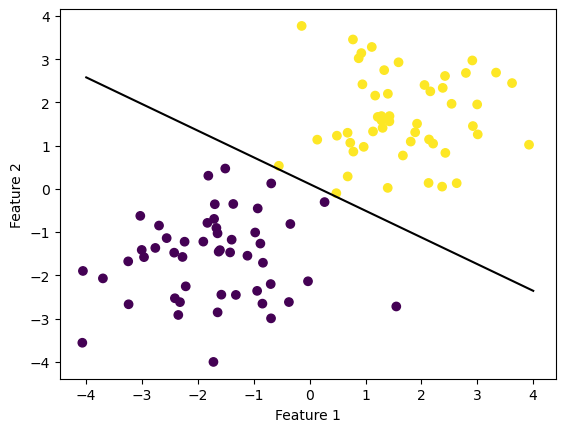

In [7]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = p.draw_line(p.w, -4, 4)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

# Perceptron Algorithm on Data which is <u>not</u> Linearly Separable

When the data points are not linearly separable the Perceptron algorithm will not be able to settle on a weight vector - $w$ - which perfectly divides the data points into two regions. In theoretical terms this means that based on the $2$ features, the Perceptron algorithm is not able to come up with a weight vector $w$, which can predict with $100%$ accuracy, whether an object belongs to one group or another. For example - building up on our original example - based on a person's $(1)$ age, and $(2)$ salary, the Perceptron algorithm is not able to predict whether this person will buy a car or not. 

In order to visualize data which is not linearly separable, we will follow the same steps as before, the only change would be in the line: 
```python
    X, y = make_blobs(n_samples = n, n_features = features, centers = [(-1.7,-1.7),(1.7,1.7)])
```
We can change the centers of the two clusterings, to make them have overlaps. Something like:
```python
    X, y = make_blobs(n_samples = n, n_features = features, centers = [(0.5,0.5),(1.7,1.7)])
```

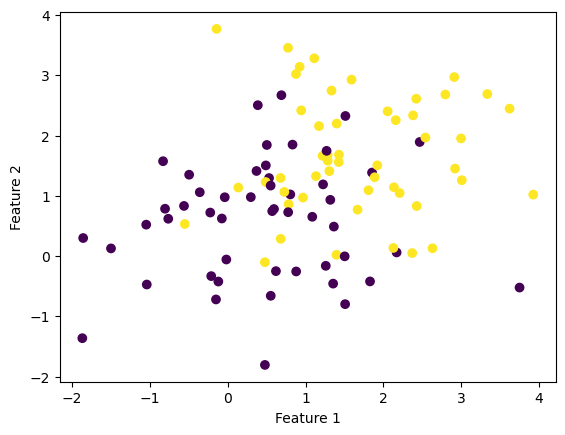

In [8]:
#importing the necessary packages
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from perceptron import Perceptron 

np.random.seed(12345)

n = 100
features = 2

X, y = make_blobs(n_samples = n, n_features = features, centers = [(0.5,0.5),(1.7,1.7)])

#plotting the clusters generated by the make_blobs function
fig = plt.scatter(X[:,0], X[:,1], c = y)
xLabel = plt.xlabel("Feature 1")
yLabel = plt.ylabel("Feature 2")

Therefore, we can clearly see that the two types of data (objects) have more overlap now, and are not linearly separable. That is, you cannot imagine a straight line which divides the data points into two regions perfectly. 

In this situation, since the Perceptron algorithm will never reach the situation in which the <i>score</i> is 1.0 - it will stop running once it reaches the specified number of <i>max_steps</i>. This experiment will seek to explore what happens as the number of <i>max_steps</i> is increased. First, let us start with the same magnitude of <i>max_steps</i> as the previos linearly separable case, that is: <i>max_steps = 1500</i>

In [9]:
#creating an instance of the Perceptron class
p = Perceptron()
#max_steps - number of times we will go over the dataset
p.fit(X, y, max_steps = 1500)

Clearly, we can see that the maximum score that we are able to achieve is 0.71! Furthermore, we can see that our accuracy was better off in the beginning, when the weight vector $w$ was almost random. 

[0.51, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.78, 0.78]
0.78


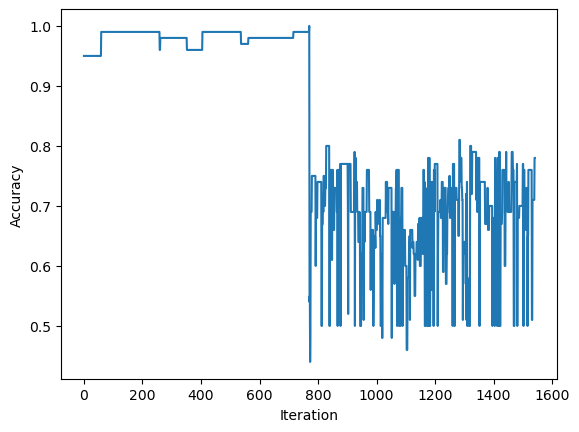

In [10]:
print(p.history[-10:]) 
p.visualize_score()
print(p.score(X,y))

Even in the final line we achieve, we can see that it does not perfectly separate the data into two regions!

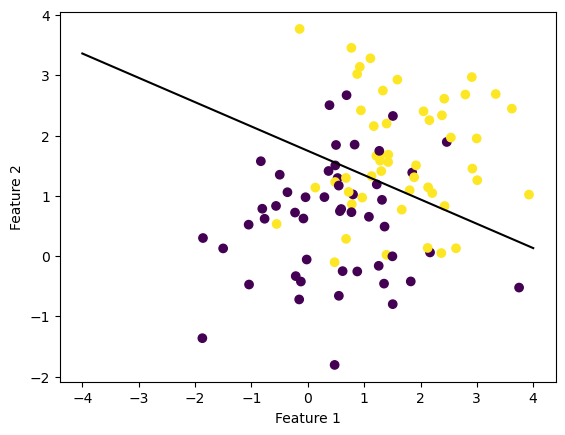

In [11]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = p.draw_line(p.w, -4, 4)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

Now, let us try to increase the <i>max_steps</i> to an aribtrarily large number, say <i>max_steps=50000</i>

In [12]:
p_new = Perceptron()
p_new.fit(X, y, max_steps=50000)

Clearly, we can see that the maximum score we achieve is 0.7!

[0.76, 0.67, 0.67, 0.67, 0.67, 0.67, 0.67, 0.67, 0.77, 0.68]
0.68


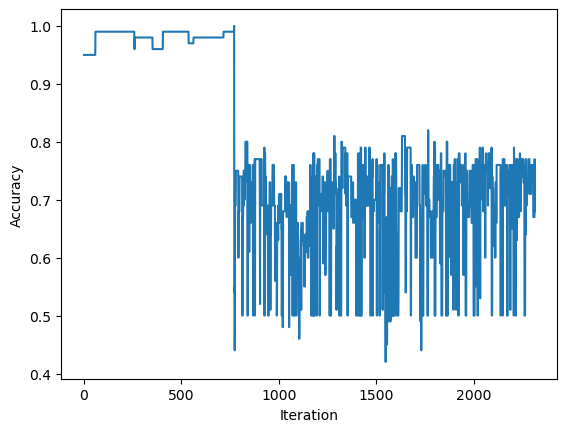

In [13]:
print(p_new.history[-10:]) 
p_new.visualize_score()
print(p_new.score(X,y))

Even in the final line we achieve, we can see that it does not perfectly separate the data into two regions! By running for $50,000$ data points instead of $1500$, our score did not change a lot. Therefore, we can tell that if the data is not linearly separable - the perceptron does not converege!

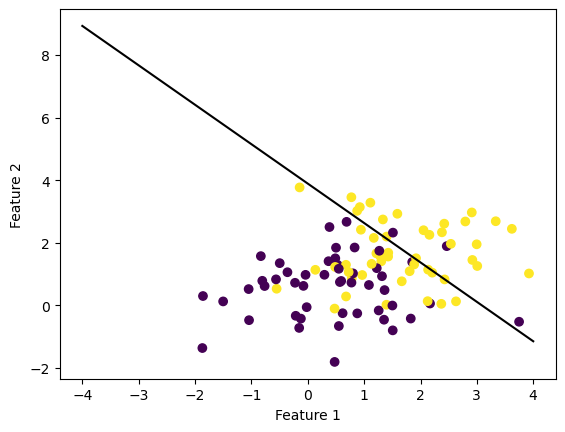

In [14]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = p_new.draw_line(p_new.w, -4, 4)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

# Perceptron Algorithm in <i>n</i> = 5 Dimension (5 Features)